In [2]:
import numpy as np
import pandas as pd
import time

In [3]:
url='https://raw.githubusercontent.com/sakshi2k/Social_Network_Ads/refs/heads/master/Social_Network_Ads.csv'
df=pd.read_csv(url)
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [4]:
df = df[['Age','EstimatedSalary','Purchased']]
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [5]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [6]:
print(X_scaled.shape)
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape

(400, 2)


(320, 2)

In [7]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [8]:
model = Sequential()

model.add(Dense(10,activation='relu',input_dim=2))
model.add(Dense(10,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

C:\Users\narin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

stochastic gd (batch size 1)

In [14]:
model.compile(loss='binary_crossentropy',metrics=['accuracy'])
start = time.time()
history_s = model.fit(X_scaled,y,epochs=100,batch_size=1,validation_split=0.2)
print(time.time() - start)

Epoch 1/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8938 - loss: 0.2424 - val_accuracy: 0.9750 - val_loss: 0.2176
Epoch 2/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8813 - loss: 0.2443 - val_accuracy: 0.9750 - val_loss: 0.1995
Epoch 3/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8969 - loss: 0.2496 - val_accuracy: 0.9750 - val_loss: 0.1887
Epoch 4/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8938 - loss: 0.2543 - val_accuracy: 0.9750 - val_loss: 0.1804
Epoch 5/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8875 - loss: 0.2564 - val_accuracy: 0.9750 - val_loss: 0.1746
Epoch 6/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8969 - loss: 0.2546 - val_accuracy: 0.9750 - val_loss: 0.1702
Epoch 7/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9031 - loss: 0.2628 - val_accuracy: 0.9750 - val_loss: 0.1721
Epoch 8/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9031 - loss: 0.2657 - val_accu

batch gd(batch size=x_Train.shape)

In [13]:
model.compile(loss='binary_crossentropy',metrics=['accuracy'])
start = time.time()
history_b = model.fit(X_scaled,y,epochs=100,batch_size=320,validation_split=0.2)
print(time.time() - start)

Epoch 1/100


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.8813 - loss: 0.2542 - val_accuracy: 0.9750 - val_loss: 0.2392
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - accuracy: 0.8813 - loss: 0.2529 - val_accuracy: 0.9750 - val_loss: 0.2407
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.8813 - loss: 0.2520 - val_accuracy: 0.9750 - val_loss: 0.2420
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.8813 - loss: 0.2513 - val_accuracy: 0.9750 - val_loss: 0.2432
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.8813 - loss: 0.2508 - val_accuracy: 0.9750 - val_loss: 0.2442
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.8844 - loss: 0.2503 - val_accuracy: 0.9750 - val_loss: 0.2451
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 0.8844 - loss: 0.2499 - val_accuracy: 0.9750 - val_loss: 0.2460
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 0.8844 - loss: 0.2495 - val_accuracy: 0.9750 - val_loss: 0.2467

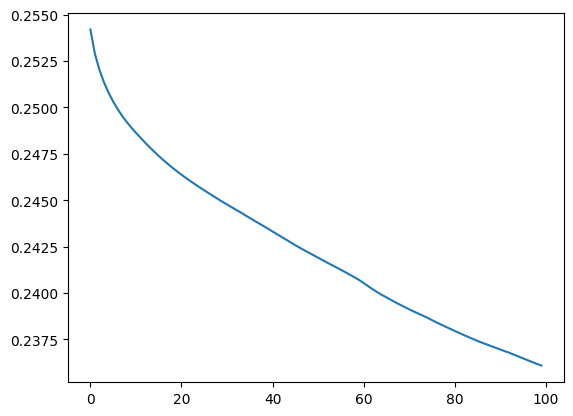

In [15]:
import matplotlib.pyplot as plt
plt.plot(history_b.history['loss'])